# Advanced Image Classification with ImageNet

In this assignment, you will be asked to develop a convolutional neural network (CNN) to classify images from the CIFAR-100 dataset. At each step, you'll be guided through the process of developing a model architecture to solve a problem. Your goal is to create a CNN that attains at least 55% accuracy on the validation set.

### The CIFAR-100 Dataset

The [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html) consists of 60000 32x32 colour images in 100 classes, with 600 images per class. There are 50000 training images and 10000 test images. The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 500 images from each class.

### Tools

You will use Keras with TensorFlow to develop your CNN. For this assignment, it's strongly recommended that you use a GPU to accelerate your training, or else you might find it difficult to train your network in a reasonable amount of time. If you have a computer with a GPU that you wish to use, you can follow the [TensorFlow instructions](https://www.tensorflow.org/install/) for installing TensorFlow with GPU support. Otherwise, you can use [Google Colab](https://colab.research.google.com/) to complete this assignment. Colab provides free access to GPU-enabled machines. If you run into any issues, please contact us as soon as possible so that we can help you resolve them.

## Task 1: Data Exploration and Preprocessing (Complete or Incomplete)
### 1a: Load and Explore the Dataset
- Use the code below to download the dataset.
- Explore the dataset: examine the shape of the training and test sets, the dimensions of the images, and the number of classes. Show a few examples from the training set.

In [24]:
from keras.datasets import cifar100

# Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

In [25]:
class_names = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]

In [26]:
import matplotlib.pyplot as plt
import numpy as np

In [27]:
# Shapes of training and test data sets
x_train.shape, x_test.shape, y_train.shape, y_test.shape


((50000, 32, 32, 3), (10000, 32, 32, 3), (50000, 1), (10000, 1))

In [28]:
# Image dimension
x_train.shape[1:]

(32, 32, 3)

In [29]:
# Number of classes
len(set(y_train.flatten()))

100

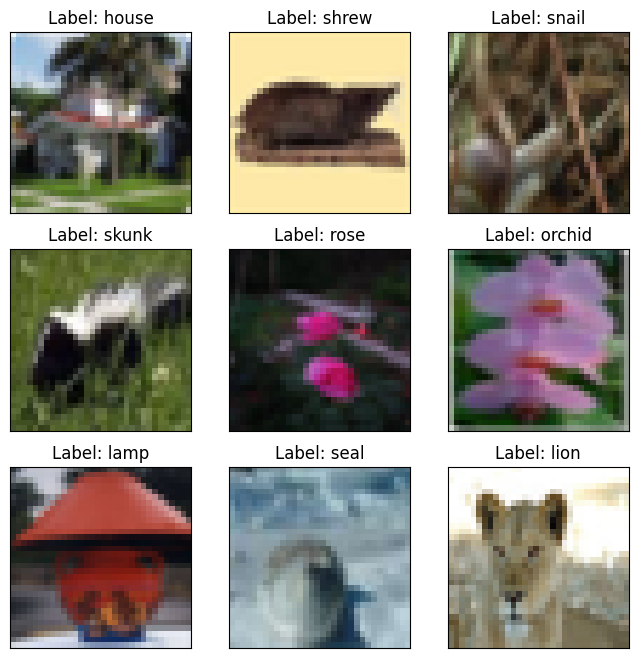

In [30]:
# Showing few examples from the training set
#Selecting 9 random indices
random_indices = np.random.choice(len(x_train), 9, replace=False)

# Creating a 3x3 grid plot
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[random_indices[i]], cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f"Label: {class_names[y_train[random_indices[i]][0]]}")

    # Removing axis labels
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

### 1b: Data Preprocessing
- With the data downloaded, it's time to preprocess it. Start by normalizing the images so that they all have pixel values in the range [0, 1].
- Next, convert the labels to one-hot encoded vectors.
- Finally, split the training set into training and validation sets. Use 80% of the training set for training and the remaining 20% for validation.

In [31]:
# Normalizing the image
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

In [32]:
# Convert the labels to one-hot encoded vectors
from tensorflow.keras.utils import to_categorical

print(f'Before one-hot encoding: {y_train[0]}')
y_train = to_categorical(y_train, num_classes= 100)
y_test = to_categorical(y_test, num_classes= 100)
print(f'After one-hot encoding: {y_train[0]}')

Before one-hot encoding: [19]
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


In [33]:
# Split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2, # 20% of the data is used for testing
    random_state=42 # Providing a value here means getting the same "random" split every time
)

In [38]:
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'y_val shape: {y_val.shape}')

X_train shape: (40000, 32, 32, 3)
y_train shape: (40000, 100)
X_val shape: (10000, 32, 32, 3)
y_val shape: (10000, 100)


## Task 2: Model Development (Complete or Incomplete)
### Task 2a: Create a Baseline CNN Model
- Design a CNN architecture. Your architecture should use convolutional layers, max pooling layers, and dense layers. You can use any number of layers, and you can experiment with different numbers of filters, filter sizes, strides, padding, etc. The design doesn't need to be perfect, but it should be unique to you.
- Print out the model summary.

In [35]:
# Your Code Here
from tensorflow.keras import layers, models
# Define the model
model = models.Sequential()

# First Convolutional block
model.add (layers.Conv2D (32, (3,3), activation= 'relu', input_shape= (32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

# Second Convolutional block
model.add (layers.Conv2D (64, (3,3), activation= 'relu'))
model.add(layers.MaxPooling2D((2,2)))

# Flatten the features
model.add(layers.Flatten())

# Dense layer
model.add(layers.Dense(64,activation= 'relu'))

# Output layer
model.add(layers.Dense(100,activation= 'softmax'))

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 100)                 │           6,500 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 173,412 (677.39 KB)

 Trainable params: 173,412 (677.39 KB)

 Non-trainable params: 0 (0.00 B)

### Task 2b: Compile the model

- Select an appropriate loss function and optimizer for your model. These can be ones we have looked at already, or they can be different.
- Briefly explain your choices (one or two sentences each).
- <b>Loss function:</b> I used categorical crossentropy as it is suitable for multiclass classification problems.
- <b>Optimizer:</b> I used Adam optimizer as it is generally effective for wide range of problems

In [36]:
# Your Code Here
from tensorflow.keras.optimizers import Adam
model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer= Adam(), # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)


## Task 3: Model Training and Evaluation (Complete or Incomplete)
### Task 3a: Train the Model

- Train your model for an appropriate number of epochs. Explain your choice of the number of epochs used - you can change this number before submitting your assignment.
- Use a batch size of 32.
- Use the validation set for validation.

In [40]:
# Your Code Here
model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs= 5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_data = (X_val, y_val) # Use 20% of the data for validation
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - accuracy: 0.4852 - loss: 1.9127 - val_accuracy: 0.3411 - val_loss: 2.7676
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 84s 38ms/step - accuracy: 0.4949 - loss: 1.8678 - val_accuracy: 0.3429 - val_loss: 2.7806
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - accuracy: 0.5064 - loss: 1.8269 - val_accuracy: 0.3327 - val_loss: 2.8484
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 38ms/step - accuracy: 0.5088 - loss: 1.8026 - val_accuracy: 0.3263 - val_loss: 2.9117
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 38ms/step - accuracy: 0.5172 - loss: 1.7701 - val_accuracy: 0.3411 - val_loss: 2.8750


The number of epochs selected is 5. Model was trained initially with 5 epochs and reached to the validation accuracy of of around 34%. With testing with number of epoches with 10 , and 20, model did not improved, It continued to loose validation accuracy and continued to increase validation loss. So, the number of epochs selected is 5.

### Task 3b: Accuracy and other relevant metrics on the test set

- Report the accuracy of your model on the test set.
- While accuracy is a good metric, there are many other ways to numerically evaluate a model. Report at least one other metric, and explain what it measures and how it is calculated.

- <b>Accuracy:</b> _34.11%_____
- <b>Other metric:</b> __Validation loss____
- <b>Reason for selection:</b> _It is selected as it explains how well the model is performnig on unseen data.
- <b>Value of metric:</b> __2.87____
- <b>Interpretation of metric value:</b> A high vlaidation loss (2.87) indicates that model is not performing well on the validation data. It might be because of overfitting, or model has memorized the training data and fails to generalize.

In [42]:
# Your Code Here
loss, accuracy = model.evaluate(X_val, y_val)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3446 - loss: 2.8644
Loss:     2.88
Accuracy: 34.11%


### Task 3c: Visualize the model's learning

- Plot the training accuracy and validation accuracy with respect to epochs.
- Select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.
- Briefly discuss the results. What do the plots show? Do the results make sense? What do the classification probabilities indicate?

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - accuracy: 0.5640 - loss: 1.5713
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 87s 40ms/step - accuracy: 0.5672 - loss: 1.5567
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 79s 38ms/step - accuracy: 0.5715 - loss: 1.5306
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 78s 35ms/step - accuracy: 0.5795 - loss: 1.4917
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 35ms/step - accuracy: 0.5923 - loss: 1.4525


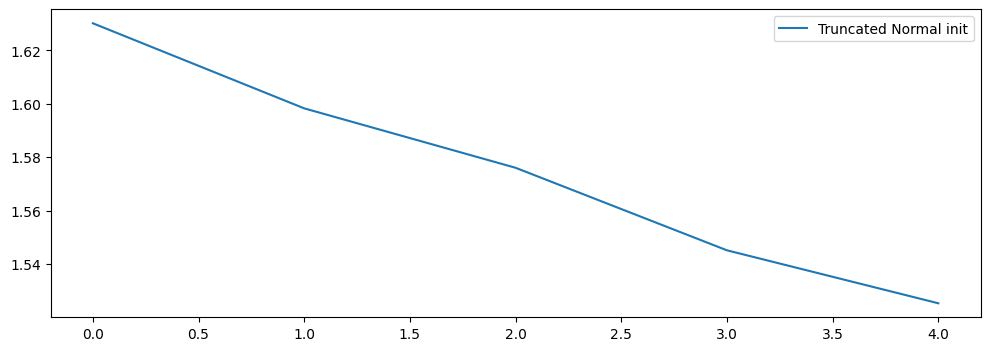

In [44]:
# Your Code Here
history = model.fit(X_train, y_train, epochs= 5, batch_size=32)

plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label="Truncated Normal init")
plt.legend();

## Task 4: Model Enhancement (Complete or Incomplete)
### Task 4a: Implementation of at least one advanced technique

- Now it's time to improve your model. Implement at least one technique to improve your model's performance. You can use any of the techniques we have covered in class, or you can use a technique that we haven't covered. If you need inspiration, you can refer to the [Keras documentation](https://keras.io/).
- Explain the technique you used and why you chose it.
- If you used a technique that requires tuning, explain how you selected the values for the hyperparameters.

In [51]:
# Your Code Here
# Using dropout for model enhancement
# Define model with dropouts
model_dropout = models.Sequential()

# First Convolutional block
model_dropout.add (layers.Conv2D (32, (3,3), activation= 'relu', input_shape= (32,32,3)))
model_dropout.add(layers.MaxPooling2D((2,2)))
model_dropout.add(layers.Dropout(0.25)) # Dropout layer with 25% dropout rate

# Second Convolutional block
model_dropout.add (layers.Conv2D (64, (3,3), activation= 'relu'))
model_dropout.add(layers.MaxPooling2D((2,2)))
model_dropout.add(layers.Dropout(0.25)) # Dropout layer with 25% dropout rate

# Flatten the features
model_dropout.add(layers.Flatten())

# Dense layer
model_dropout.add(layers.Dense(64,activation= 'relu'))
model_dropout.add(layers.Dropout(0.25)) # Dropout layer with 25% dropout rate

# Output layer
model_dropout.add(layers.Dense(100,activation= 'softmax'))

model_dropout.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 100)                 │           6,500 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 173,412 (677.39 KB)

 Trainable params: 173,412 (677.39 KB)

 Non-trainable params: 0 (0.00 B)

### Task 4b: Evaluation of the enhanced model

- Re-train your model using the same number of epochs as before.
- Compare the accuracy and other selected metric on the test set to the results you obtained before.
- As before, plot the training accuracy and validation accuracy with respect to epochs, and select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.

In [52]:
# Compile the model
model_dropout.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer= Adam(), # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

In [55]:
# Train the model with dropouts
model_dropout.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs= 10, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_data = (X_val, y_val) # Use 20% of the data for validation
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.1994 - loss: 3.2712 - val_accuracy: 0.2678 - val_loss: 3.0295
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 84s 42ms/step - accuracy: 0.2112 - loss: 3.2017 - val_accuracy: 0.2684 - val_loss: 3.0183
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 52s 41ms/step - accuracy: 0.2173 - loss: 3.1539 - val_accuracy: 0.2848 - val_loss: 2.9200
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.2309 - loss: 3.1082 - val_accuracy: 0.2895 - val_loss: 2.8922
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.2406 - loss: 3.0609 - val_accuracy: 0.3053 - val_loss: 2.8459
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.2456 - loss: 3.0249 - val_accuracy: 0.3024 - val_loss: 2.8659
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 52s 41ms/step - accuracy: 0.2518 - loss: 2.9843 - val_accuracy: 0.3075 - val_loss: 2.8243
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.2566 -

### Task 4c: Discussion of the results

- Briefly discuss the results.

- Did the model's performance improve?

- Why do you think this is?

- Do you think there is room for further improvement? Why or why not?

- What other techniques might you try in the future?


# Your answer here

I selected the droput method for model enhancement. With dropouts model shows low accuracy for training (26.8%) and validation (30.8%) sets. Model performance decreased with dropouts.
With dropouts model performs poor for both training and validation sets, it might be because model is very simple with regard to data set.
In my opinin, model can be improved by adding more convoluted layers, it might has not performed well because of the lesser number of layers in the model than the model in actual requires to perform efficiently.
In the future to increase the model performance, I will add more convolutional blocks to the model, add more dense layers, and will subsequently increase the number of neurons in the dense layers.

## Criteria

|Criteria|Complete|Incomplete|
|----|----|----|
|Task 1|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 2|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 3|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 4|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.